In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
# import matplotlib.colors as mcolors
# from wrf_io import postproc
from itertools import product

import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.interpolate import griddata
from torch.utils.data import DataLoader, TensorDataset


In [2]:
rotor_10 = IEA10MW()

NameError: name 'IEA10MW' is not defined

In [ ]:
# Generate r and theta inputs
t_10_r = np.linspace(0,2*np.pi,158)
r_10_r = np.array([0.04288751, 0.08042134, 0.11795516, 0.15548898, 0.19302281,0.23055663, 0.26809045, 0.30562428, 0.3431581 , 0.38069192,0.41822574, 0.45575957, 0.49329339, 0.53082721, 0.56836104,0.60589486, 0.64342868, 0.6809625 , 0.71849633, 0.75603015,0.79356397, 0.8310978 , 0.86863162, 0.90616544, 0.94369927,0.98123309])
R_10_r, T_10_r = np.meshgrid(r_10_r, t_10_r)

R_10_t, T_10_t = R_10_r, T_10_r

In [4]:
avgs_10MW = np.load("../wrf/rotor_coeffs/shapiro/10MW_local_averages.npy")

In [5]:
# Construct vectors of veer rates

veer_10 = np.array([-80,-40,-20,-10,0,10,20,40,80])/199

shear_10 = np.array([-6,-4,-2,0,2,4,6])/199

training = [pair for pair in product(shear_10, veer_10)]
shear_train = [x for x, y in training]
veer_train = [y for x, y in training]

In [10]:
# Construct ind and Ct vectors

for i in range(len(shear_train)):
    print(f'({shear_train[i]:>8.5f}, {veer_train[i]:>8.5f}, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,{i}], avgs_10MW[1,:,:,{i}]),')
    # print(f'({shear_15[i]:>6.3f}, {veer_15[i]:>6.3f}, R_15_t.T, T_15_t.T, avgs_15MW[0,:,:,{i}], avgs_15MW[1,:,:,{i}]),')
    # print(f'({shear_22[i]:>6.3f}, {veer_22[i]:>6.3f}, R_22_t.T, T_22_t.T, avgs_22MW[0,:,:,{i}], avgs_22MW[1,:,:,{i}]),')    

(-0.03015, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,0], avgs_10MW[1,:,:,0]),
(-0.03015, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,1], avgs_10MW[1,:,:,1]),
(-0.03015, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,2], avgs_10MW[1,:,:,2]),
(-0.03015, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,3], avgs_10MW[1,:,:,3]),
(-0.03015,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,4], avgs_10MW[1,:,:,4]),
(-0.03015,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,5], avgs_10MW[1,:,:,5]),
(-0.03015,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,6], avgs_10MW[1,:,:,6]),
(-0.03015,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,7], avgs_10MW[1,:,:,7]),
(-0.03015,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,8], avgs_10MW[1,:,:,8]),
(-0.02010, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,9], avgs_10MW[1,:,:,9]),
(-0.02010, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,10], avgs_10MW[1,:,:,10]),
(-0.02010, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,11], avgs_10MW[1,:,:,11]),
(-0.02010, -

## NN extension to full shear sweep

### Inputs:  r, theta, CT, shear, veer

### Outputs: a

In [6]:
# 1. Prepare the dataset with multiple (z1, z2) cases
def prepare_data(dataset_list):
    """Takes a list of (z1, z2, x_matrix, y_matrix) and prepares training data."""
    all_ind_train = []
    all_ct_train = []
    all_ind_val = []
    all_ct_val = []

    for shear, veer, radius, theta, ind_matrix, ct_matrix in dataset_list:
        r_flat = radius.flatten()
        theta_flat = theta.flatten()
        ind_flat = ind_matrix.flatten()
        ct_flat = ct_matrix.flatten()
        shear_flat = np.full_like(r_flat, shear)
        veer_flat = np.full_like(r_flat, veer)

        # New inputs: (r, θ, z1, z2, y)
        inputs = np.column_stack([r_flat, theta_flat, shear_flat, veer_flat, ct_flat])
        outputs = np.column_stack([ind_flat])  # Predicting only x

        # Shuffle and split (80% train, 20% validation)
        indices = np.random.permutation(inputs.shape[0])
        split_idx = int(0.8 * inputs.shape[0])
        train_idx, val_idx = indices[:split_idx], indices[split_idx:]

        all_ind_train.append(inputs[train_idx])
        all_ct_train.append(outputs[train_idx])
        all_ind_val.append(inputs[val_idx])
        all_ct_val.append(outputs[val_idx])

    # Stack into final training and validation sets
    ind_train = np.vstack(all_ind_train)
    ct_train = np.vstack(all_ct_train)
    ind_val = np.vstack(all_ind_val)
    ct_val = np.vstack(all_ct_val)

    return ind_train, ct_train, ind_val, ct_val

# 2. Define a simple feed-forward neural network
class XY_Predictor(nn.Module):
    def __init__(self):
        super(XY_Predictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(5, 64),  # Input size changed from 4 → 5
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # Output size changed from 2 → 1 (predicting x only)
        )

    def forward(self, x):
        return self.model(x)

# 3. Training function
def train_model(model, train_loader, val_loader, epochs=100, lr=0.001):
    """Train the neural network."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_val_batch, Y_val_batch in val_loader:
                val_predictions = model(X_val_batch)
                val_loss += criterion(val_predictions, Y_val_batch).item()

        # Print progress
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.6f}, "
              f"Val Loss: {val_loss/len(val_loader):.6f}")

# 4. Prepare dataset and train the model
# Example dataset list: [(z1_1, z2_1, x_matrix_1, y_matrix_1), (z1_2, z2_2, x_matrix_2, y_matrix_2), ...]
# Example dataset list: [shear rate, veer rate, r, theta, induction, CT]
dataset_list = [
    (-0.03015, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,0], avgs_10MW[1,:,:,0]),
    (-0.03015, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,1], avgs_10MW[1,:,:,1]),
    (-0.03015, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,2], avgs_10MW[1,:,:,2]),
    (-0.03015, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,3], avgs_10MW[1,:,:,3]),
    (-0.03015,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,4], avgs_10MW[1,:,:,4]),
    (-0.03015,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,5], avgs_10MW[1,:,:,5]),
    (-0.03015,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,6], avgs_10MW[1,:,:,6]),
    (-0.03015,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,7], avgs_10MW[1,:,:,7]),
    (-0.03015,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,8], avgs_10MW[1,:,:,8]),
    (-0.02010, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,9], avgs_10MW[1,:,:,9]),
    (-0.02010, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,10], avgs_10MW[1,:,:,10]),
    (-0.02010, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,11], avgs_10MW[1,:,:,11]),
    (-0.02010, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,12], avgs_10MW[1,:,:,12]),
    (-0.02010,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,13], avgs_10MW[1,:,:,13]),
    (-0.02010,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,14], avgs_10MW[1,:,:,14]),
    (-0.02010,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,15], avgs_10MW[1,:,:,15]),
    (-0.02010,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,16], avgs_10MW[1,:,:,16]),
    (-0.02010,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,17], avgs_10MW[1,:,:,17]),
    (-0.01005, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,18], avgs_10MW[1,:,:,18]),
    (-0.01005, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,19], avgs_10MW[1,:,:,19]),
    (-0.01005, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,20], avgs_10MW[1,:,:,20]),
    (-0.01005, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,21], avgs_10MW[1,:,:,21]),
    (-0.01005,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,22], avgs_10MW[1,:,:,22]),
    (-0.01005,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,23], avgs_10MW[1,:,:,23]),
    (-0.01005,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,24], avgs_10MW[1,:,:,24]),
    (-0.01005,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,25], avgs_10MW[1,:,:,25]),
    (-0.01005,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,26], avgs_10MW[1,:,:,26]),
    ( 0.00000, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,27], avgs_10MW[1,:,:,27]),
    ( 0.00000, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,28], avgs_10MW[1,:,:,28]),
    ( 0.00000, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,29], avgs_10MW[1,:,:,29]),
    ( 0.00000, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,30], avgs_10MW[1,:,:,30]),
    ( 0.00000,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,31], avgs_10MW[1,:,:,31]),
    ( 0.00000,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,32], avgs_10MW[1,:,:,32]),
    ( 0.00000,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,33], avgs_10MW[1,:,:,33]),
    ( 0.00000,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,34], avgs_10MW[1,:,:,34]),
    ( 0.00000,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,35], avgs_10MW[1,:,:,35]),
    ( 0.01005, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,36], avgs_10MW[1,:,:,36]),
    ( 0.01005, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,37], avgs_10MW[1,:,:,37]),
    ( 0.01005, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,38], avgs_10MW[1,:,:,38]),
    ( 0.01005, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,39], avgs_10MW[1,:,:,39]),
    ( 0.01005,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,40], avgs_10MW[1,:,:,40]),
    ( 0.01005,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,41], avgs_10MW[1,:,:,41]),
    ( 0.01005,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,42], avgs_10MW[1,:,:,42]),
    ( 0.01005,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,43], avgs_10MW[1,:,:,43]),
    ( 0.01005,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,44], avgs_10MW[1,:,:,44]),
    ( 0.02010, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,45], avgs_10MW[1,:,:,45]),
    ( 0.02010, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,46], avgs_10MW[1,:,:,46]),
    ( 0.02010, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,47], avgs_10MW[1,:,:,47]),
    ( 0.02010, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,48], avgs_10MW[1,:,:,48]),
    ( 0.02010,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,49], avgs_10MW[1,:,:,49]),
    ( 0.02010,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,50], avgs_10MW[1,:,:,50]),
    ( 0.02010,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,51], avgs_10MW[1,:,:,51]),
    ( 0.02010,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,52], avgs_10MW[1,:,:,52]),
    ( 0.02010,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,53], avgs_10MW[1,:,:,53]),
    ( 0.03015, -0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,54], avgs_10MW[1,:,:,54]),
    ( 0.03015, -0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,55], avgs_10MW[1,:,:,55]),
    ( 0.03015, -0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,56], avgs_10MW[1,:,:,56]),
    ( 0.03015, -0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,57], avgs_10MW[1,:,:,57]),
    ( 0.03015,  0.00000, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,58], avgs_10MW[1,:,:,58]),
    ( 0.03015,  0.05025, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,59], avgs_10MW[1,:,:,59]),
    ( 0.03015,  0.10050, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,60], avgs_10MW[1,:,:,60]),
    ( 0.03015,  0.20101, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,61], avgs_10MW[1,:,:,61]),
    ( 0.03015,  0.40201, R_10_t.T, T_10_t.T, avgs_10MW[0,:,:,62], avgs_10MW[1,:,:,62]),
]

X_train, Y_train, X_val, Y_val = prepare_data(dataset_list)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
Y_val_tensor = torch.tensor(Y_val, dtype=torch.float32)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, Y_val_tensor)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize model
model = XY_Predictor()

# Train the model
train_model(model, train_loader, val_loader, epochs=64)

# 5. Evaluation function
def evaluate_model(model, r, theta, z1_eval, z2_eval, y_true, x_true):
    """Evaluate the model on a specific (z1, z2) case."""
    # Prepare input
    X_eval = np.column_stack([r.flatten(), theta.flatten(),
                              np.full_like(r.flatten(), z1_eval),
                              np.full_like(r.flatten(), z2_eval),
                              y_true.flatten()])  # Add y as input
    X_eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    # Get predictions
    model.eval()
    with torch.no_grad():
        predictions = model(X_eval_tensor).numpy()

    # Reshape predictions
    x_pred = predictions[:, 0].reshape(r.shape)

    return x_pred

torch.save(model.state_dict(), "./NN_models/E128_L3_N64_Arelu_15.pth")


Epoch 1/64, Train Loss: 0.000694, Val Loss: 0.000443
Epoch 2/64, Train Loss: 0.000326, Val Loss: 0.000395
Epoch 3/64, Train Loss: 0.000209, Val Loss: 0.000336
Epoch 4/64, Train Loss: 0.000147, Val Loss: 0.000134
Epoch 5/64, Train Loss: 0.000112, Val Loss: 0.000084
Epoch 6/64, Train Loss: 0.000099, Val Loss: 0.000077
Epoch 7/64, Train Loss: 0.000089, Val Loss: 0.000092
Epoch 8/64, Train Loss: 0.000081, Val Loss: 0.000069
Epoch 9/64, Train Loss: 0.000073, Val Loss: 0.000055
Epoch 10/64, Train Loss: 0.000069, Val Loss: 0.000052
Epoch 11/64, Train Loss: 0.000064, Val Loss: 0.000050
Epoch 12/64, Train Loss: 0.000062, Val Loss: 0.000049
Epoch 13/64, Train Loss: 0.000059, Val Loss: 0.000048
Epoch 14/64, Train Loss: 0.000055, Val Loss: 0.000072
Epoch 15/64, Train Loss: 0.000054, Val Loss: 0.000040
Epoch 16/64, Train Loss: 0.000052, Val Loss: 0.000060
Epoch 17/64, Train Loss: 0.000051, Val Loss: 0.000047
Epoch 18/64, Train Loss: 0.000050, Val Loss: 0.000037
Epoch 19/64, Train Loss: 0.000049, Va

In [ ]:
# torch.save(model.state_dict(), "./NN_models/E128_L3_N64_Arelu_15.pth")

import torch
import torch.nn as nn
import torch.optim as optim


In [6]:
class XY_Predictor(nn.Module):
    def __init__(self):
        super(XY_Predictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(5, 64),  # Input size changed from 4 → 5
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # Output size changed from 2 → 1 (predicting x only)
        )

    def forward(self, x):
        return self.model(x)

# 5. Evaluation function
def evaluate_model(model, r, theta, z1_eval, z2_eval, y_true, x_true):
    """Evaluate the model on a specific (z1, z2) case."""
    # Prepare input
    X_eval = np.column_stack([r.flatten(), theta.flatten(),
                              np.full_like(r.flatten(), z1_eval),
                              np.full_like(r.flatten(), z2_eval),
                              y_true.flatten()])  # Add y as input
    X_eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    # Get predictions
    model.eval()
    with torch.no_grad():
        predictions = model(X_eval_tensor).numpy()

    # Reshape predictions
    x_pred = predictions[:, 0].reshape(r.shape)

    return x_pred
    
model_load = XY_Predictor()
model_load.load_state_dict(torch.load("/scratch/09909/smata/induction_modeling/FF_NN_modeling/NN_models/E128_L3_N64_Arelu_15.pth"))

<All keys matched successfully>

/tmp/ipykernel_758122/578565437.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[coords[count][1],coords[count][0]].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=1,label='Ground truth')
/tmp/ipykernel_758122/578565437.py:23: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax[coords[count][1],coords[count][0]].scatter(x_pred, y_true, cmap='viridis', s=30, edgecolor='none',color='r',alpha=0.085,label='Prediction')


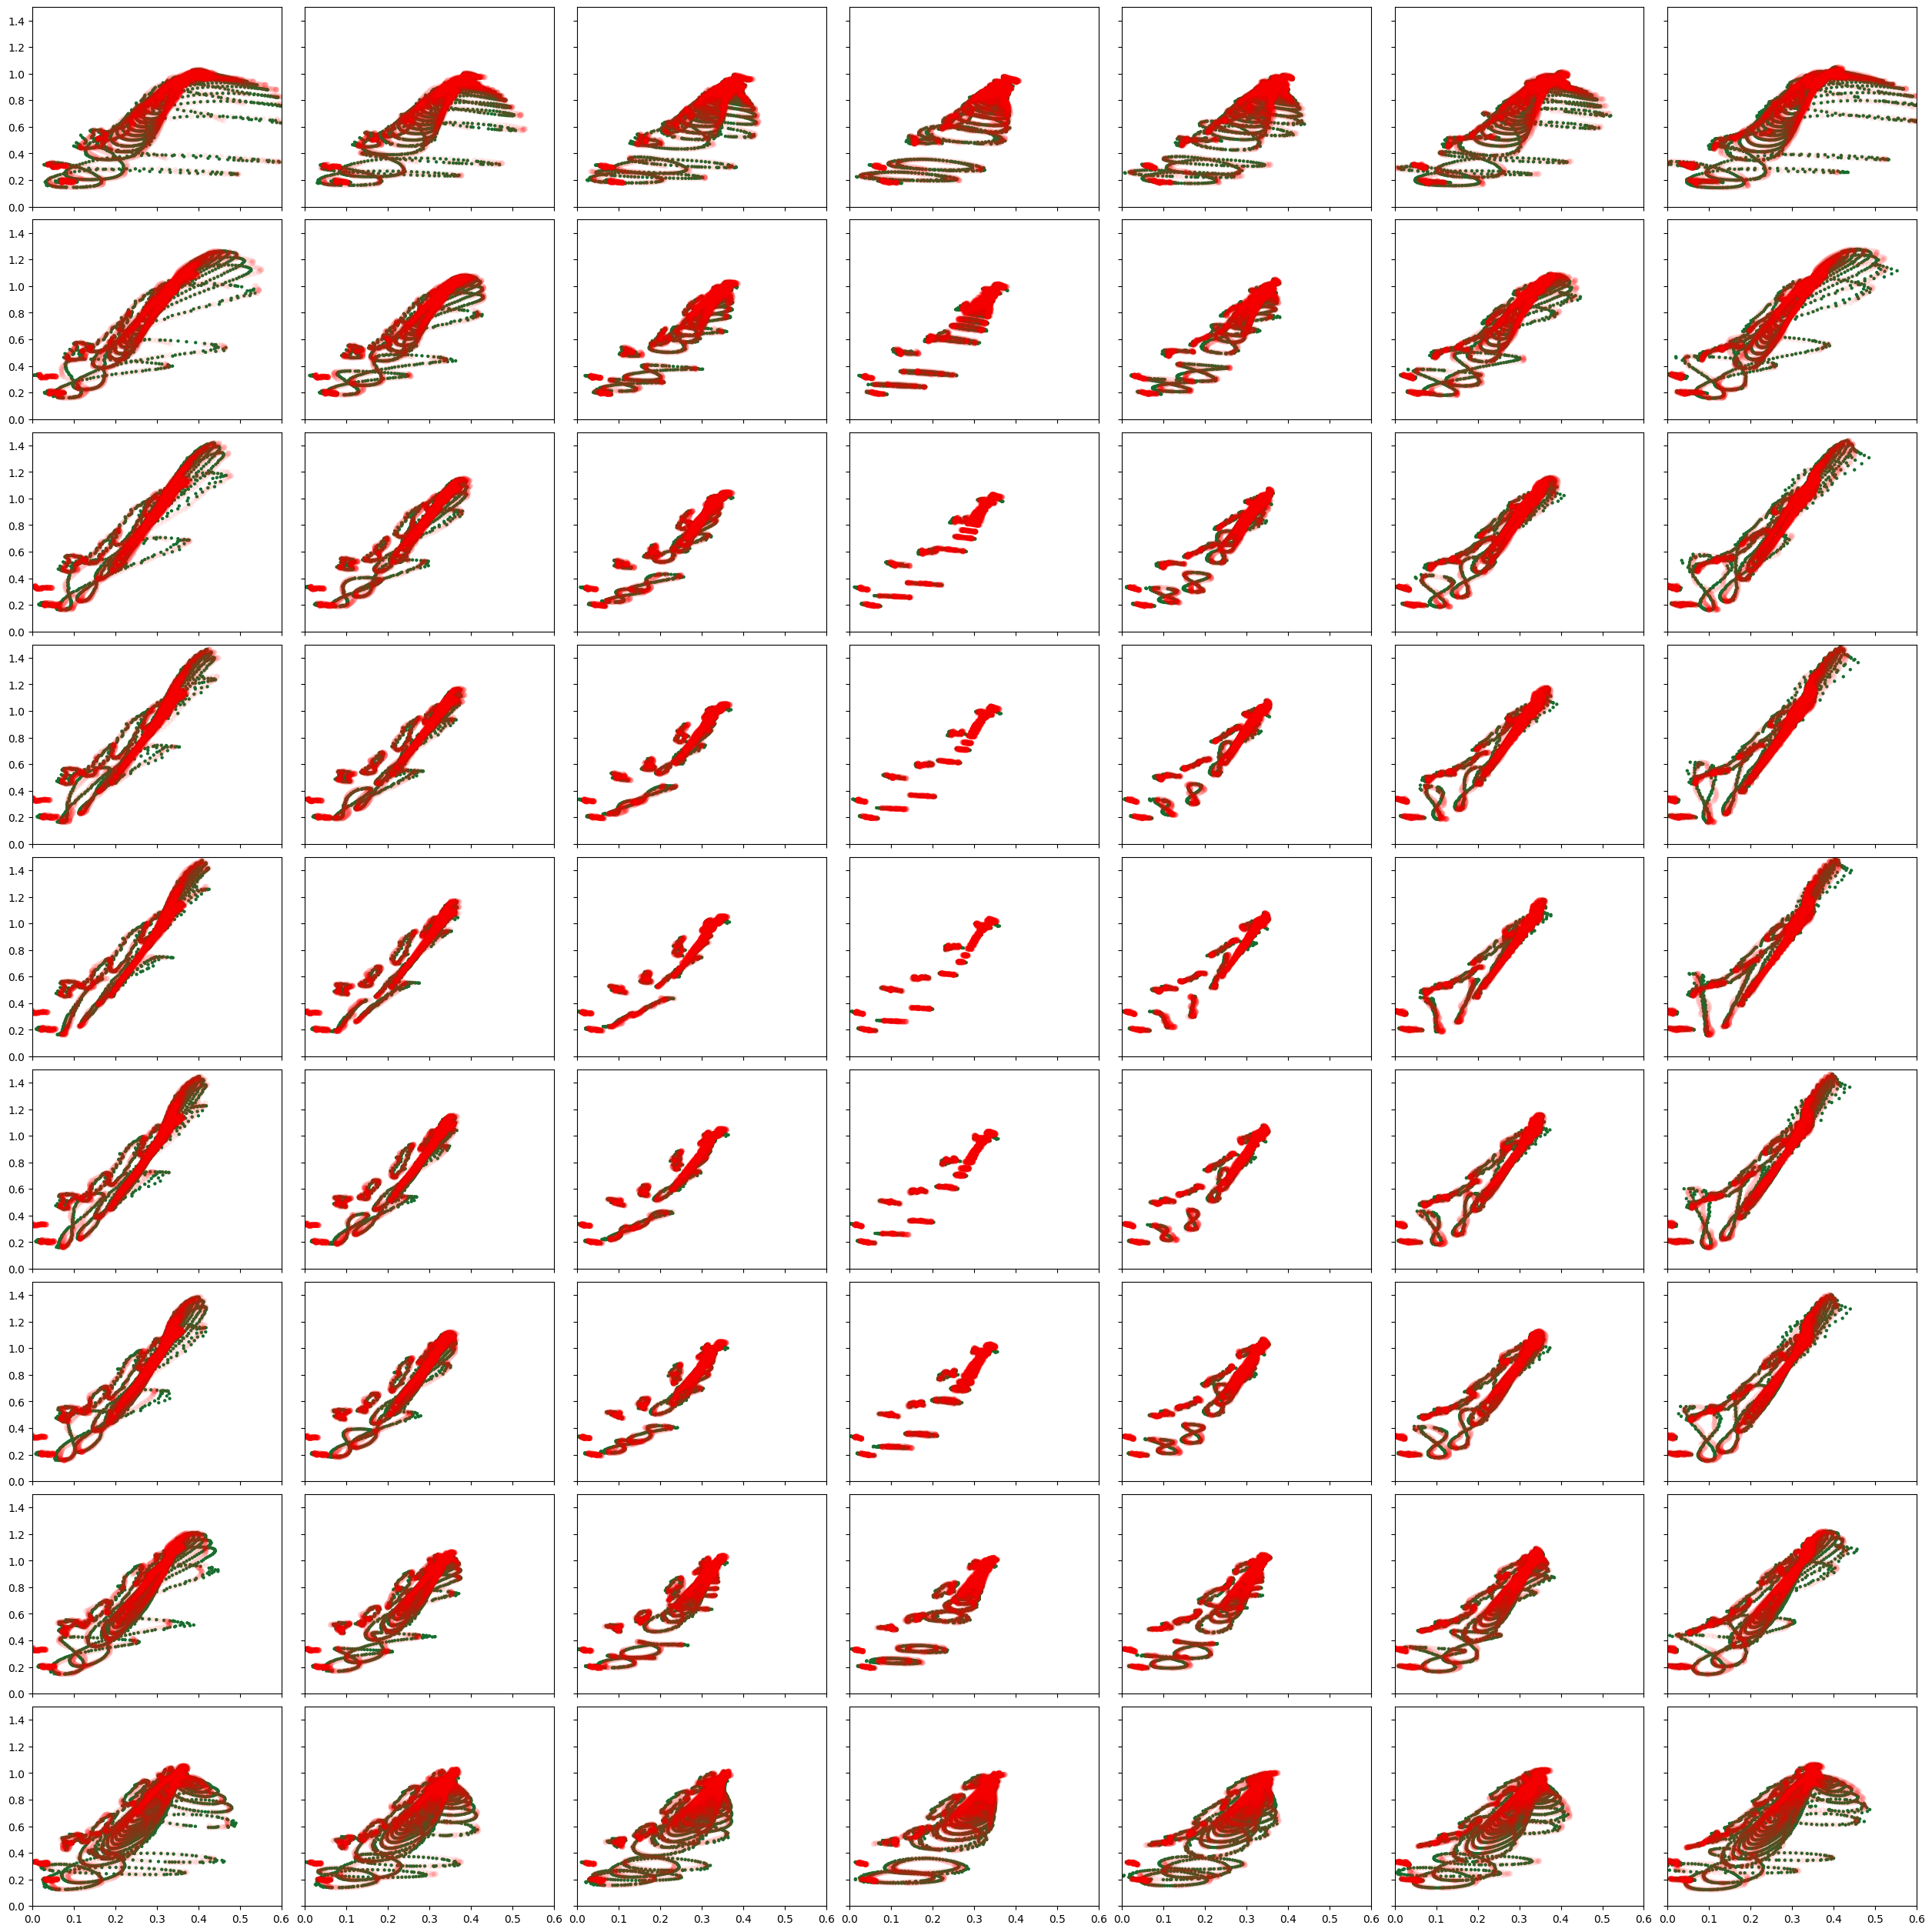

In [8]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]


v_ref = veer_train
s_ref = shear_train

ref_15MW = np.load("../wrf/rotor_coeffs/shapiro/10MW_local_averages.npy")

ind = ref_15MW[0,:,:,:]
ct = ref_15MW[1,:,:,:]

fig, ax = plt.subplots(nrows=9, ncols=7, figsize=(25, 25), constrained_layout=True,sharex=True, sharey=True)

for count in range(len(v_ref)):

    y_true = ct[:,:,count]
    x_true = ind[:,:,count]  # Retrieve true x, y
    x_pred = evaluate_model(model_load, R_10_r.T, T_10_r.T, s_ref[count], v_ref[count], y_true, x_true)

    ax[coords[count][1],coords[count][0]].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=1,label='Ground truth')
    ax[coords[count][1],coords[count][0]].scatter(x_pred, y_true, cmap='viridis', s=30, edgecolor='none',color='r',alpha=0.085,label='Prediction')

    # ax[xs[count],ys[count]].set_aspect('equal')
    ax[coords[count][1],coords[count][0]].set_xlim([0,0.6])
    ax[coords[count][1],coords[count][0]].set_ylim([0,1.5])

plt.show()

In [7]:
ref_15MW = np.load("../wrf/rotor_coeffs/shapiro/10MW_local_averages.npy")

ind = ref_15MW[0,:,:,:]
ct = ref_15MW[1,:,:,:]

x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]


v_ref = veer_train
s_ref = shear_train

y_true = ct[:,:,31]
x_true = ind[:,:,31]  # Retrieve true x, y
x_pred = evaluate_model(model_load, R_10_r.T, T_10_r.T, s_ref[31], v_ref[31], y_true, x_true)
x_pred

array([[0.01479295, 0.01519194, 0.01544882, ..., 0.01632363, 0.01642352,
        0.01652291],
       [0.02678572, 0.02657486, 0.02654369, ..., 0.0301815 , 0.02927646,
        0.02788614],
       [0.08153573, 0.08082229, 0.08122571, ..., 0.07866766, 0.07711999,
        0.0756342 ],
       ...,
       [0.25649512, 0.25568524, 0.25378796, ..., 0.24975838, 0.2503056 ,
        0.25255063],
       [0.19298178, 0.19282028, 0.19260967, ..., 0.18531194, 0.18383667,
        0.18329057],
       [0.12869826, 0.12770332, 0.12773536, ..., 0.13397002, 0.13286668,
        0.13089219]], shape=(26, 158), dtype=float32)

In [11]:
from MITRotor import BEM, IEA10MW, BEMGeometry, KraghAerodynamics, NeuralNetInduction, PrandtlTipLoss, DefaultTangentialInduction
from pathlib import Path

In [12]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [13]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [14]:
casenames = [
r'sn030151_vn402010',
r'sn030151_vn201005',
r'sn030151_vn100503',
r'sn030151_vn050251',
r'sn030151_v000000',
r'sn030151_v050251',
r'sn030151_v100503',
r'sn030151_v201005',
r'sn030151_v402010',
r'sn020101_vn402010',
r'sn020101_vn201005',
r'sn020101_vn100503',
r'sn020101_vn050251',
r'sn020101_v000000',
r'sn020101_v050251',
r'sn020101_v100503',
r'sn020101_v201005',
r'sn020101_v402010',
r'sn010050_vn402010',
r'sn010050_vn201005',
r'sn010050_vn100503',
r'sn010050_vn050251',
r'sn010050_v000000',
r'sn010050_v050251',
r'sn010050_v100503',
r'sn010050_v201005',
r'sn010050_v402010',
r's000000_vn402010',
r's000000_vn201005',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010',
r's010050_vn402010',
r's010050_vn201005',
r's010050_vn100503',
r's010050_vn050251',
r's010050_v000000',
r's010050_v050251',
r's010050_v100503',
r's010050_v201005',
r's010050_v402010',
r's020101_vn402010',
r's020101_vn201005',
r's020101_vn100503',
r's020101_vn050251',
r's020101_v000000',
r's020101_v050251',
r's020101_v100503',
r's020101_v201005',
r's020101_v402010',
r's030151_vn402010',
r's030151_vn201005',
r's030151_vn100503',
r's030151_vn050251',
r's030151_v000000',
r's030151_v050251',
r's030151_v100503',
r's030151_v201005',
r's030151_v402010'
]

In [15]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * rotor.R + 378

In [17]:
rotor = IEA10MW()

bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=nElements, Ntheta=nSections), aerodynamic_model=KraghAerodynamics(), tiploss_model=PrandtlTipLoss(), momentum_model=NeuralNetInduction(), tangential_induction_model=DefaultTangentialInduction())

pitch, tsr, yaw = np.deg2rad(0), 9.410, np.deg2rad(0.0)
sol = bem(pitch, tsr, yaw)

z = sol.geom.mu_mesh * rotor.R * np.cos(sol.geom.theta_mesh) + 378

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5), constrained_layout=True,sharex=True, sharey=True)

ax.scatter(U,)


np.float64(0.284402037548306)

In [13]:
sol.Ct()

np.float64(0.8762013022844222)

In [6]:
ref_15MW = np.load("../wrf/rotor_coeffs/shapiro/10MW_local_averages.npy")

ind = ref_15MW[0,:,:,:]
ct = ref_15MW[1,:,:,:]

x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]


v_ref = veer_train
s_ref = shear_train

/tmp/ipykernel_2112253/3241388564.py:46: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1],coords[count][0]].scatter(sol.a('sector'), sol.Ct('sector'), cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=1,zorder=3)


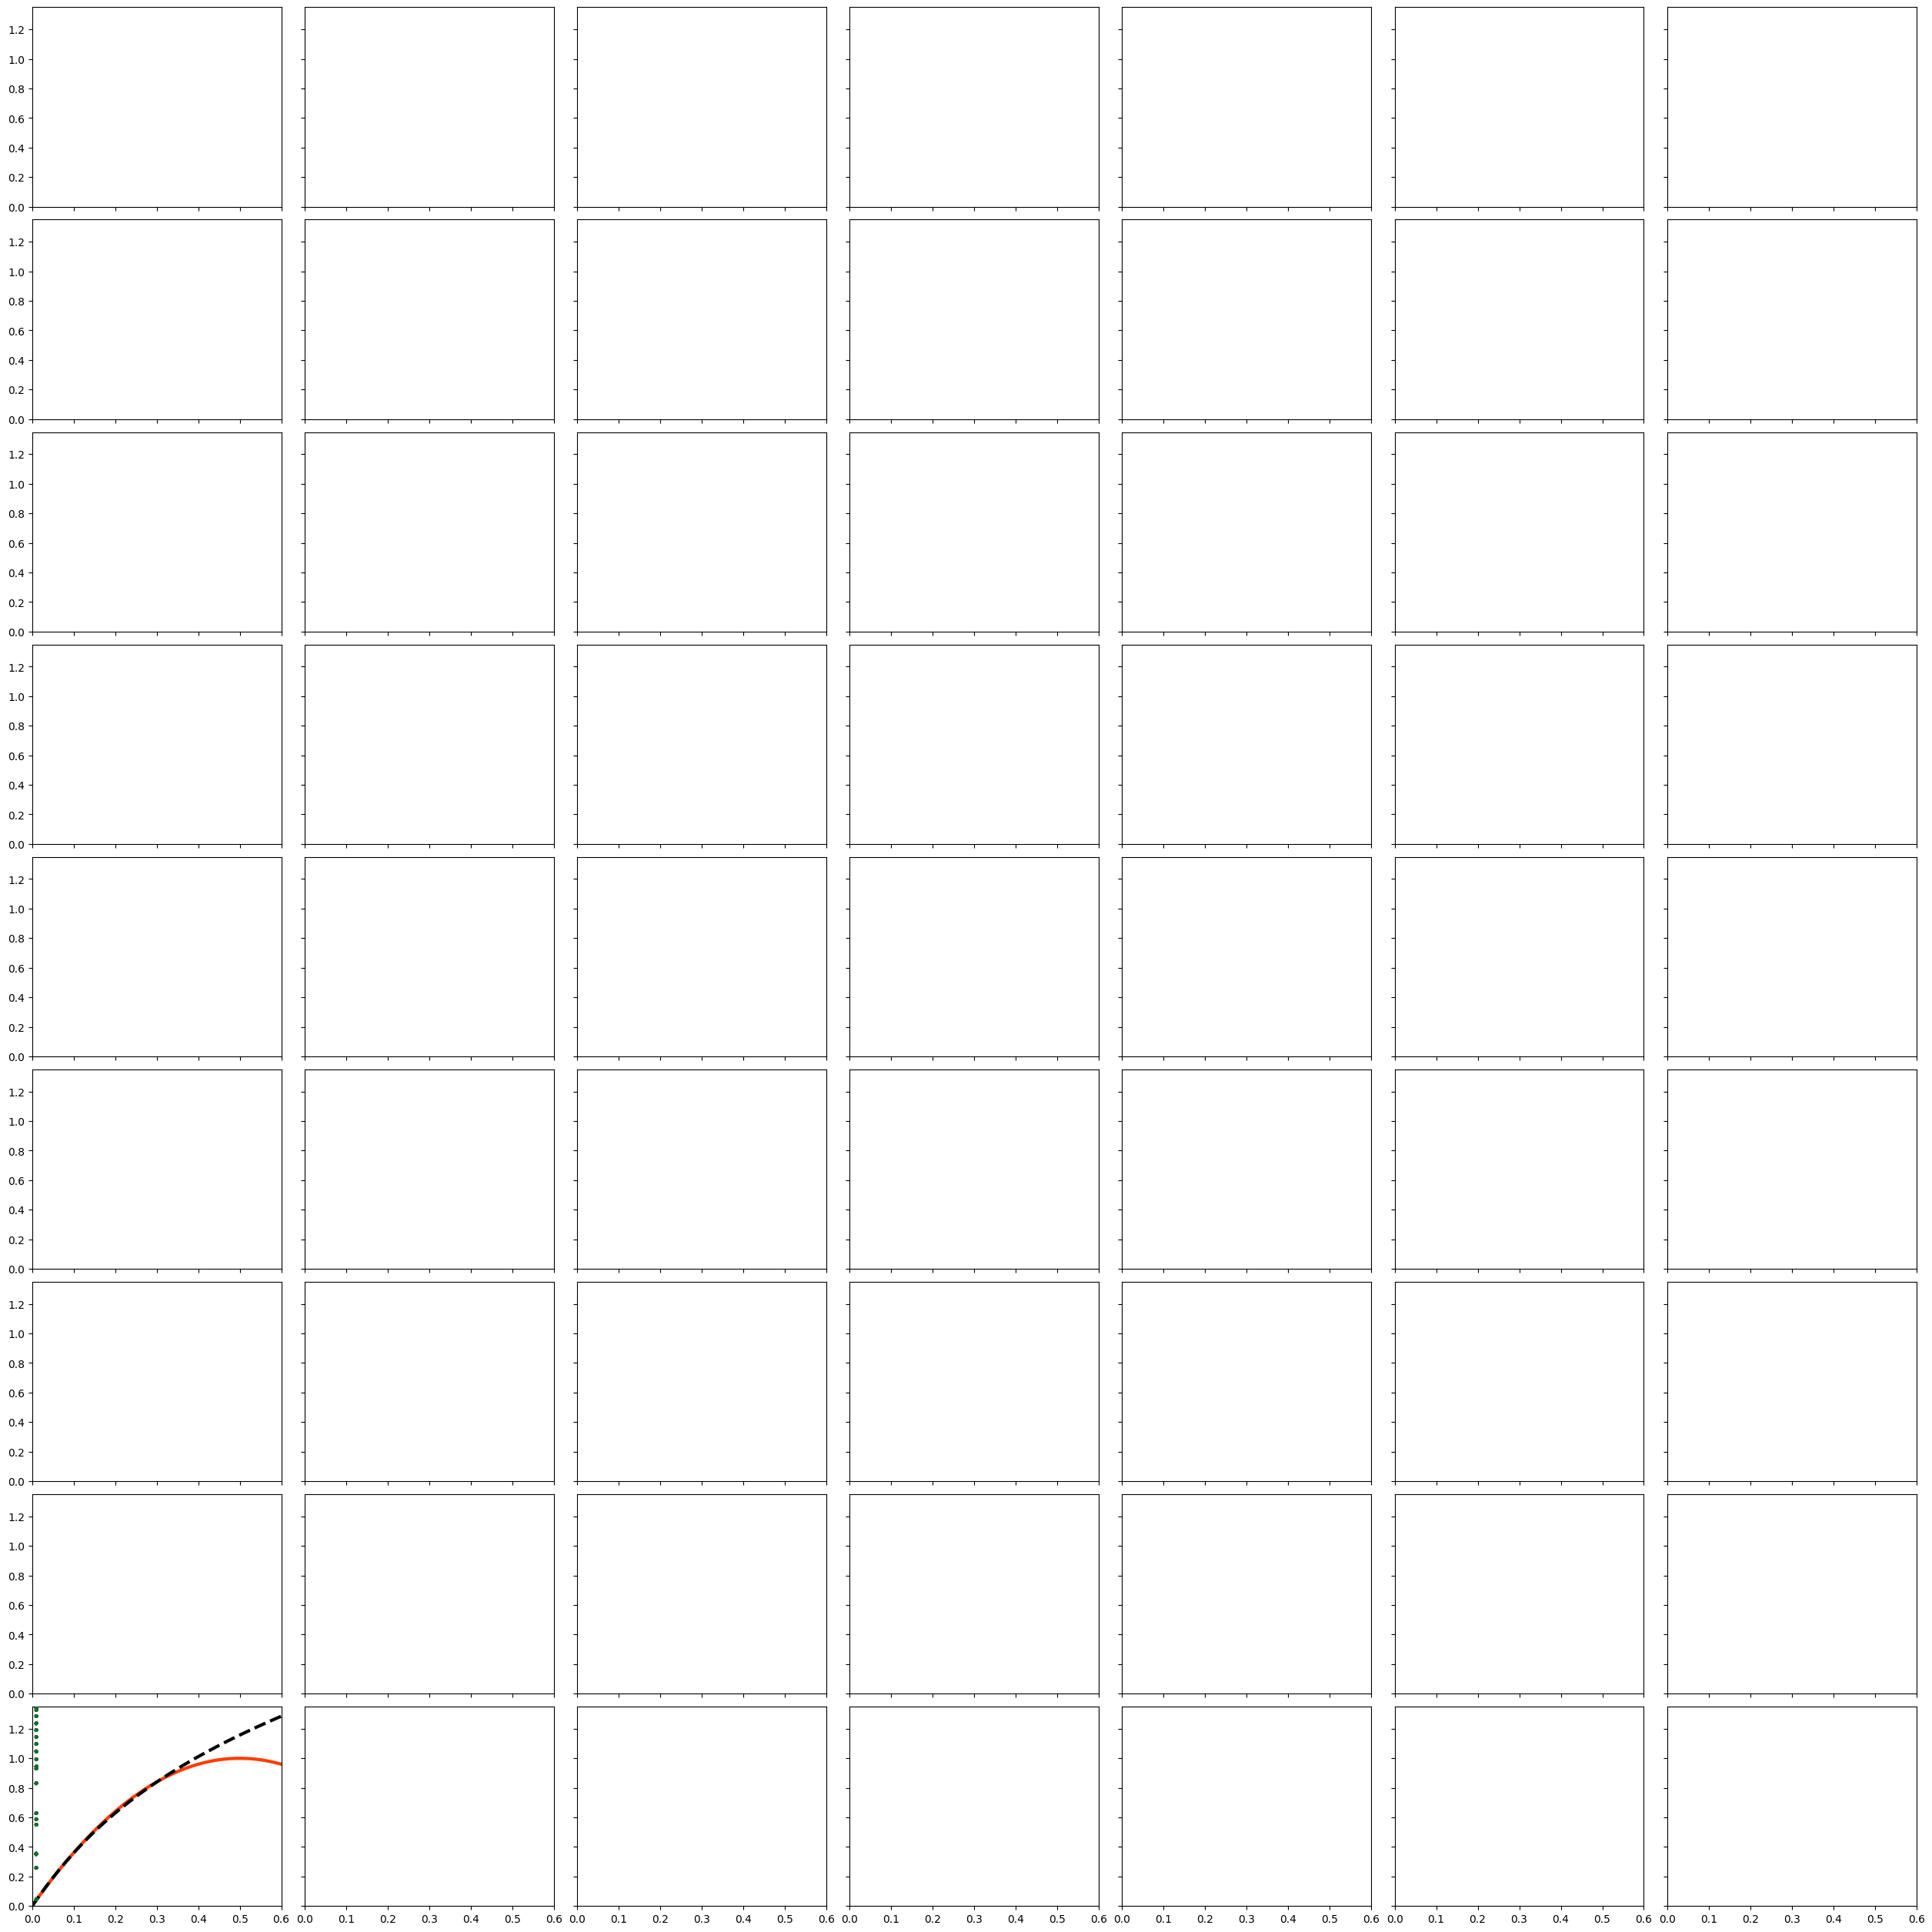

In [20]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

v_ref = veer_train
s_ref = shear_train

casenames = [r's000000_vn050251']

fig, ax = plt.subplots(nrows=9, ncols=7, figsize=(25, 25), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):
    u_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,1])
    v_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,2])

    u = u_func(z)
    v = v_func(z)

    wdir = np.atan2(v,u)

    U = (u**2 + v**2)**(1/2)

    U = u / (u**2 + v**2)**(1/2)

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=nElements, Ntheta=nSections), aerodynamic_model=KraghAerodynamics(), tiploss_model=PrandtlTipLoss(), momentum_model=NeuralNetInduction(shear=shear_train[count],veer=veer_train[count]), tangential_induction_model=DefaultTangentialInduction())
    # sol = bem(pitch, tsr, yaw, U = U/7, wdir = wdir)
    # y_true = ct[:,:,count]
    # x_true = ind[:,:,count]  # Retrieve true x, y
    # x_pred = evaluate_model(model_load, R_10_r.T, T_10_r.T, s_ref[count], v_ref[count], y_true, x_true)

    sol = bem(pitch, tsr, yaw, U = U)

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1],coords[count][0]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1],coords[count][0]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    # mesh = ax[coords[count][1],coords[count][0]].scatter(x_pred, y_true, cmap='viridis', s=10, edgecolor='none',color='red',alpha=1,zorder=3)

    mesh = ax[coords[count][1],coords[count][0]].scatter(sol.a('sector'), sol.Ct('sector'), cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=1,zorder=3)

    # ax[xs[count],ys[count]].scatter(sol.a(), sol.Ct(), cmap='viridis', s=10, edgecolor='none',color='#ffc300',zorder=4)

    # ax[xs[count],ys[count]].set_aspect('equal')
    ax[coords[count][1],coords[count][0]].set_xlim([0,0.6])
    ax[coords[count][1],coords[count][0]].set_ylim([0,1.35])

plt.show()

In [23]:
sol.geom.mu_mesh

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.0399996, 0.0399996, 0.0399996, ..., 0.0399996, 0.0399996,
        0.0399996],
       [0.0799992, 0.0799992, 0.0799992, ..., 0.0799992, 0.0799992,
        0.0799992],
       ...,
       [0.9199908, 0.9199908, 0.9199908, ..., 0.9199908, 0.9199908,
        0.9199908],
       [0.9599904, 0.9599904, 0.9599904, ..., 0.9599904, 0.9599904,
        0.9599904],
       [0.99999  , 0.99999  , 0.99999  , ..., 0.99999  , 0.99999  ,
        0.99999  ]], shape=(26, 158))

In [30]:
R_10_r.T

array([[0.04288751, 0.04288751, 0.04288751, ..., 0.04288751, 0.04288751,
        0.04288751],
       [0.08042134, 0.08042134, 0.08042134, ..., 0.08042134, 0.08042134,
        0.08042134],
       [0.11795516, 0.11795516, 0.11795516, ..., 0.11795516, 0.11795516,
        0.11795516],
       ...,
       [0.90616544, 0.90616544, 0.90616544, ..., 0.90616544, 0.90616544,
        0.90616544],
       [0.94369927, 0.94369927, 0.94369927, ..., 0.94369927, 0.94369927,
        0.94369927],
       [0.98123309, 0.98123309, 0.98123309, ..., 0.98123309, 0.98123309,
        0.98123309]], shape=(26, 158))

In [19]:
sol.aero_props.C_x

array([[0.55767771, 0.5577732 , 0.55786884, ..., 0.5955161 , 0.59526822,
        0.59502035],
       [0.31947177, 0.3208449 , 0.32274357, ..., 0.3190354 , 0.31896549,
        0.31889633],
       [0.21282719, 0.21354247, 0.21425088, ..., 0.21507935, 0.21507931,
        0.21503872],
       ...,
       [0.70432743, 0.7030495 , 0.70175798, ..., 0.71783151, 0.71608883,
        0.71437396],
       [0.5349529 , 0.5341692 , 0.53341516, ..., 0.55518174, 0.55365832,
        0.55216585],
       [0.04168647, 0.04159464, 0.04150688, ..., 0.04199838, 0.04184128,
        0.04169113]], shape=(26, 158))

In [20]:
U

array([[1.        , 1.        , 1.        , ..., 1.        , 1.        ,
        1.        ],
       [0.99961115, 0.99961176, 0.99961359, ..., 0.99961359, 0.99961176,
        0.99961115],
       [0.99857253, 0.9985748 , 0.99858157, ..., 0.99858157, 0.9985748 ,
        0.99857253],
       ...,
       [0.91898258, 0.9190361 , 0.91921036, ..., 0.91921036, 0.9190361 ,
        0.91898258],
       [0.91553579, 0.9155797 , 0.91575147, ..., 0.91575147, 0.9155797 ,
        0.91553579],
       [0.91243389, 0.91247886, 0.91266972, ..., 0.91266972, 0.91247886,
        0.91243389]], shape=(26, 158))

In [ ]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

v_ref = veer_train
s_ref = shear_train

fig, ax = plt.subplots(nrows=9, ncols=7, figsize=(25, 25), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):
    u_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,1])
    v_func = interp1d(data[casenames[count]][:,0],data[casenames[count]][:,2])

    u = u_func(z)
    v = v_func(z)

    wdir = np.atan2(v,u)

    U = (u**2 + v**2)**(1/2)

    U = u / (u**2 + v**2)**(1/2)

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=nElements, Ntheta=nSections), aerodynamic_model=KraghAerodynamics(), tiploss_model=PrandtlTipLoss(), momentum_model=NeuralNetInduction(shear=shear_train[count],veer=veer_train[count]), tangential_induction_model=DefaultTangentialInduction())
    # sol = bem(pitch, tsr, yaw, U = U/7, wdir = wdir)
    sol = bem(pitch, tsr, yaw, U = U)

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1],coords[count][0]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1],coords[count][0]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[coords[count][1],coords[count][0]].scatter(sol.a('sector'), sol.Ct('sector'), cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=1,zorder=3)

    # ax[xs[count],ys[count]].scatter(sol.a(), sol.Ct(), cmap='viridis', s=10, edgecolor='none',color='#ffc300',zorder=4)

    # ax[xs[count],ys[count]].set_aspect('equal')
    ax[coords[count][1],coords[count][0]].set_xlim([0,0.6])
    ax[coords[count][1],coords[count][0]].set_ylim([0,1.35])

plt.show()

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 0, the array at index 0 has size 35640 and the array at index 4 has size 4108

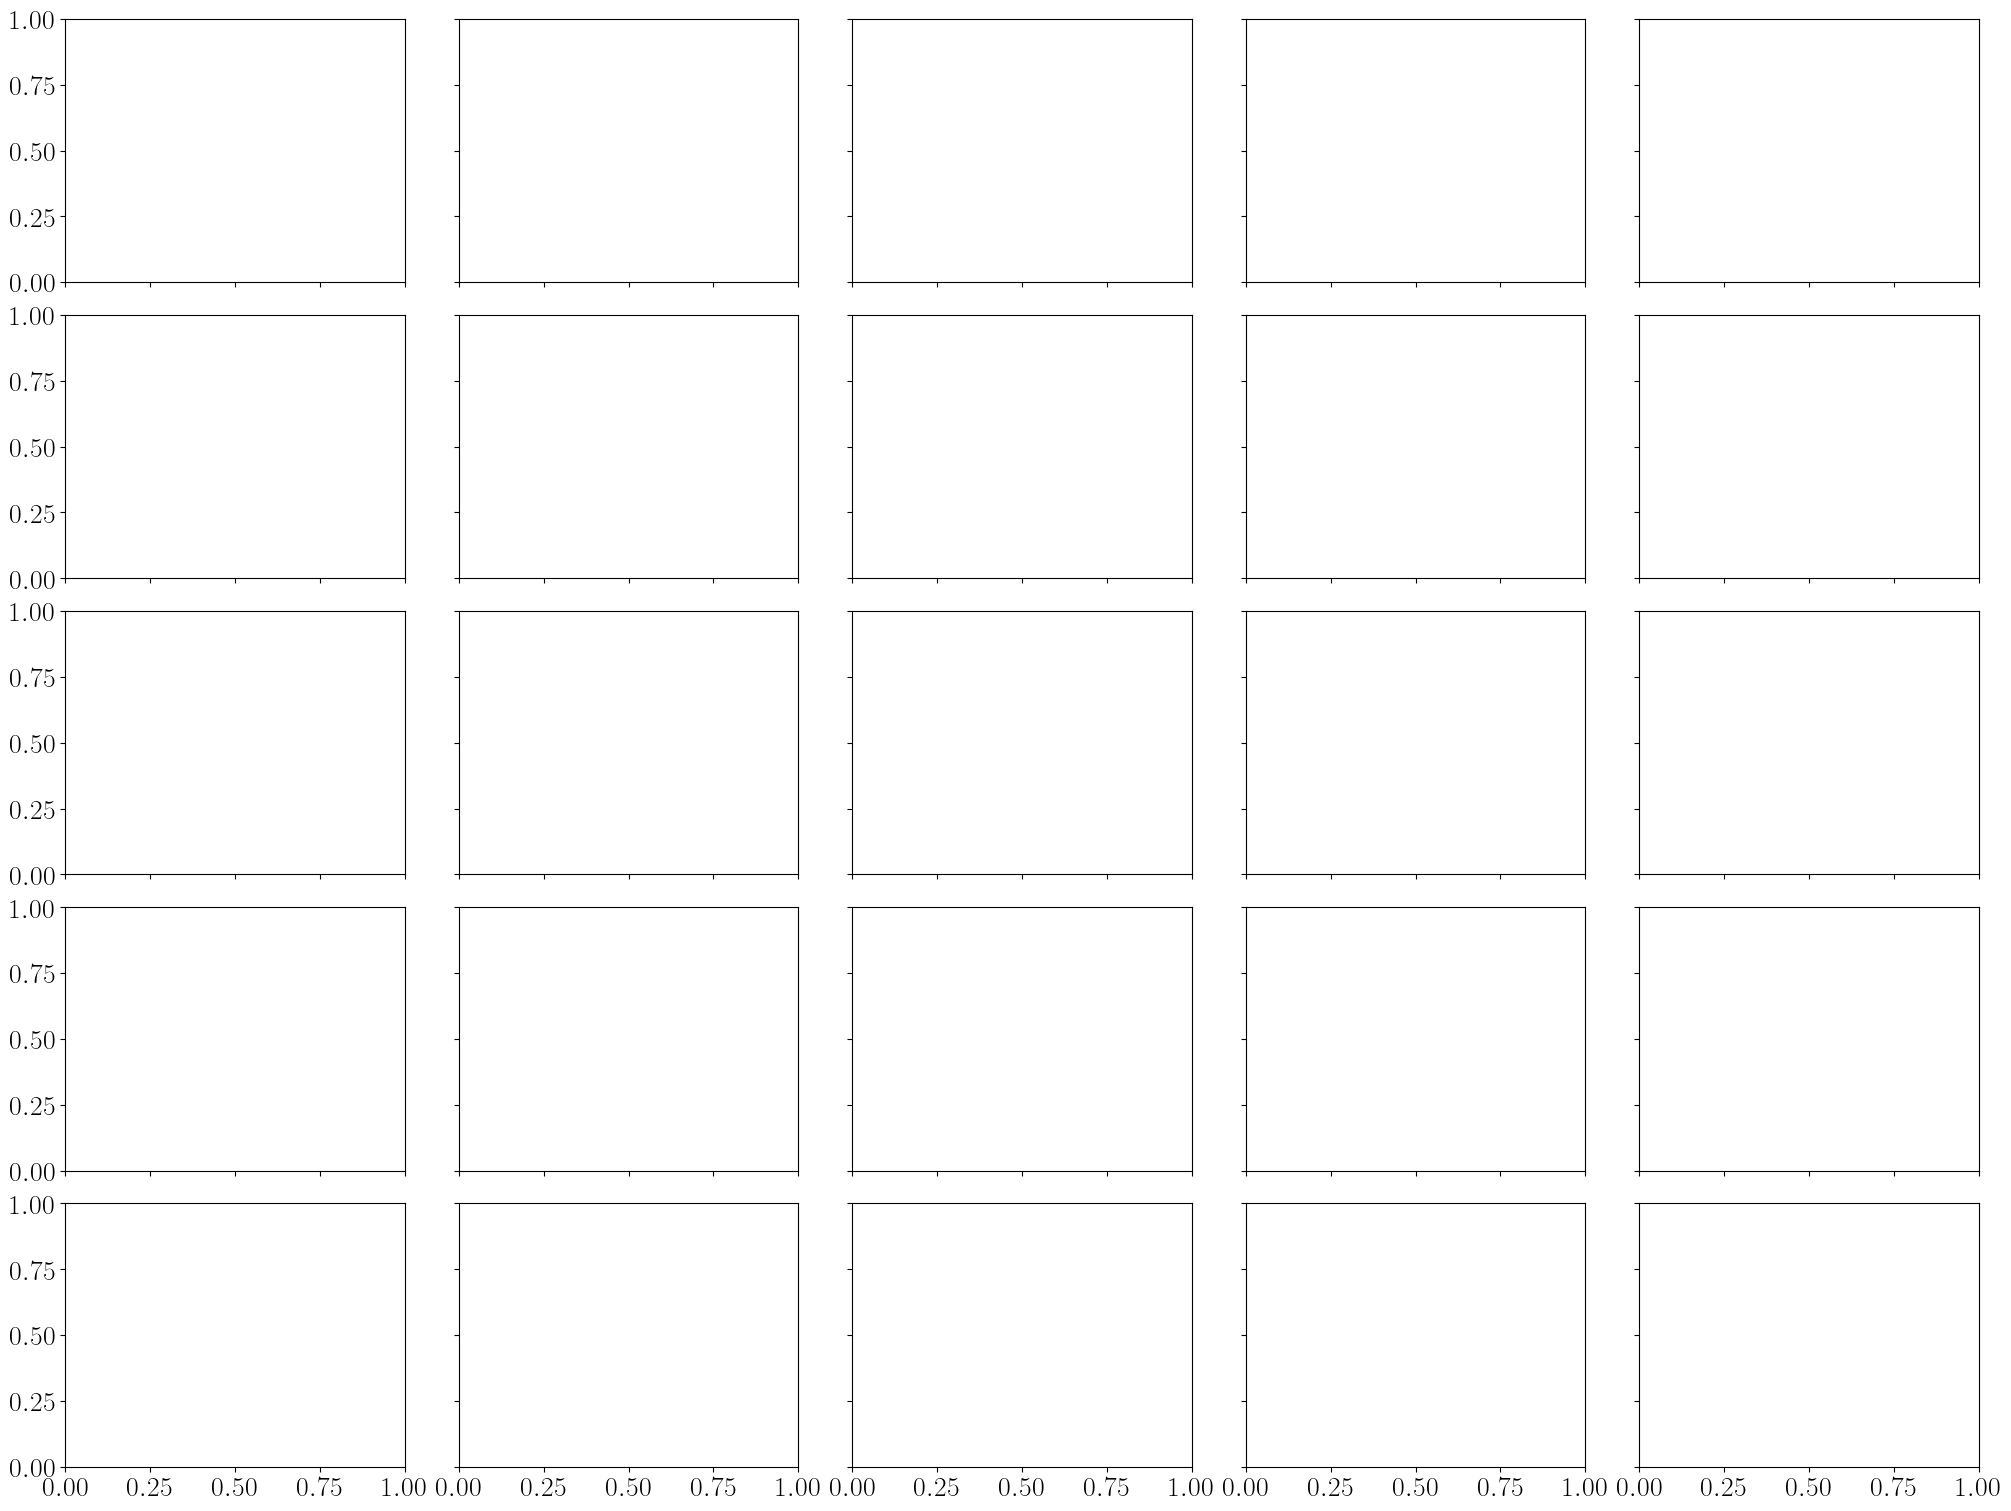

In [23]:
xs = [0,1,1,1,2,2,2,2,2,3,3,3,4]
ys = [2,1,2,3,0,1,2,3,4,1,2,3,2]

v_ref = [4, 2, 2, 2, 0, 0, 0, 0, 0, -2, -2, -2, -4]
s_ref = [0, -2, 0, 2, -4, -2, 0, 2, 4, -2, 0, 2, 0]

t = np.linspace(0,2*np.pi,360)
r = np.linspace(0,1,round(rotor.R))

R, T = np.meshgrid(r, t)

fig, ax = plt.subplots(nrows=5, ncols=5, figsize=(20, 15), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    x_true = ind[:,:,count]
    y_true = ct[:,:,count]  # Retrieve true x, y

    x_pred = evaluate_model(model, R.T, T.T, v_ref[count], s_ref[count], y_true, x_true)

    # ax[xs[count],ys[count]].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',alpha=1,label='Ground truth')
    # ax[xs[count],ys[count]].scatter(x_pred, y_true, cmap='viridis', s=30, edgecolor='none',color='r',alpha=0.085,label='Prediction')

    ax[xs[count],ys[count]].scatter(ind[:,:,count],x_pred, s=30, edgecolor='none',color='k',alpha=0.085,label='Prediction')

    # ax[xs[count],ys[count]].set_aspect('equal')
    ax[xs[count],ys[count]].set_xlim([0,0.6])
    ax[xs[count],ys[count]].set_ylim([0,0.6])

    # ax[4,4].scatter(ind[:,:,count], ct[:,:,count], cmap='viridis', s=10, edgecolor='none',color='#176d2e',zorder=3,alpha=0.05)

ax[0,0].axis('off')
ax[0,1].axis('off')
ax[0,3].axis('off')
ax[0,4].axis('off')

ax[1,0].axis('off')
ax[1,4].axis('off')

ax[3,0].axis('off')
ax[3,4].axis('off')

ax[4,0].axis('off')
ax[4,1].axis('off')
ax[4,3].axis('off')
ax[4,4].axis('off')

# Add the number line below the subplots
line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 6)+0.14  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear', ha='center', fontsize=25)


line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 6)+0.15  # Adjust the number of points and spacing
labels = ['-0.4', '-0.2', '0.0', '0.2', '0.4']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=20)

# Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear', ha='center', fontsize=25,rotation=90)

ax[0,0].scatter(-5,-5, cmap='viridis', s=100, edgecolor='none',color='#176d2e',alpha=1,label='Ground truth')
ax[0,0].scatter(-5,-5, cmap='viridis', s=100, edgecolor='none',color='r',alpha=0.7,label='Prediction')
ax[0,0].legend(loc='upper left',borderaxespad=0, fontsize=25)

# plt.figure(dpi=700)
# plt.savefig(f"./wrf_NN_.png", bbox_inches="tight", dpi=600)
plt.show()

In [22]:
round(rotor.R)

99

# LOO-CV

In [75]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# 1. Prepare the dataset with multiple (z1, z2) cases
def prepare_data(dataset_list, leave_out_idx=None):
    """Prepares training and validation data, leaving one dataset case out if specified."""
    all_X_train = []
    all_Y_train = []
    
    for i, (z1, z2, x_matrix, y_matrix) in enumerate(dataset_list):
        if i == leave_out_idx:  # Skip the leave-out case
            continue  

        r_flat = R.T.flatten()
        theta_flat = T.T.flatten()
        x_flat = x_matrix.flatten()
        y_flat = y_matrix.flatten()
        z1_flat = np.full_like(r_flat, z1)
        z2_flat = np.full_like(r_flat, z2)

        inputs = np.column_stack([r_flat, theta_flat, z1_flat, z2_flat, y_flat])
        outputs = np.column_stack([x_flat])  # Predicting only x

        all_X_train.append(inputs)
        all_Y_train.append(outputs)

    # Stack training data
    X_train = np.vstack(all_X_train)
    Y_train = np.vstack(all_Y_train)

    return X_train, Y_train

# 2. Define a simple feed-forward neural network
class XY_Predictor(nn.Module):
    def __init__(self):
        super(XY_Predictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(5, 64),  # Input: (r, θ, z1, z2, y)
            nn.ReLU(),
            # nn.Linear(64, 64),
            # nn.ReLU(),
            nn.Linear(64, 1)  # Output: x
        )

    def forward(self, x):
        return self.model(x)

# 3. Training function
def train_model(model, train_loader, epochs=100, lr=0.001):
    """Trains the neural network."""
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        train_loss = 0

        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            predictions = model(X_batch)
            loss = criterion(predictions, Y_batch)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss/len(train_loader):.6f}")

# 4. Evaluation function
def evaluate_model(model, r, theta, z1_eval, z2_eval, y_true, x_true):
    """Evaluates the model on a left-out (z1, z2) case."""
    X_eval = np.column_stack([r.flatten(), theta.flatten(),
                              np.full_like(r.flatten(), z1_eval),
                              np.full_like(r.flatten(), z2_eval),
                              y_true.flatten()])
    X_eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        predictions = model(X_eval_tensor).numpy()

    x_pred = predictions[:, 0].reshape(r.shape)
    mse = np.mean((x_pred - x_true) ** 2)  # Compute MSE

    return mse

# 5. LOO-CV function
def loo_cv(dataset_list, epochs=100, lr=0.001):
    """Performs Leave-One-Out Cross-Validation (LOO-CV) across the dataset cases."""
    loo_errors = []

    for leave_out_idx in range(len(dataset_list)):
        print(f"\nLOO Iteration {leave_out_idx+1}/{len(dataset_list)} - Leaving out case {dataset_list[leave_out_idx][0:2]}")

        # Prepare training data without the left-out case
        X_train, Y_train = prepare_data(dataset_list, leave_out_idx)

        # Convert to PyTorch tensors
        X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
        Y_train_tensor = torch.tensor(Y_train, dtype=torch.float32)

        # Create DataLoader
        train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
        train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

        # Initialize and train model
        model = XY_Predictor()
        train_model(model, train_loader, epochs=epochs, lr=lr)

        # Evaluate on left-out case
        z1_eval, z2_eval, x_true, y_true = dataset_list[leave_out_idx]
        loo_mse = evaluate_model(model, R.T, T.T, z1_eval, z2_eval, y_true, x_true)

        loo_errors.append(loo_mse)
        print(f"LOO Test Error (MSE) for left-out case {z1_eval, z2_eval}: {loo_mse:.6f}")

    avg_loo_error = np.mean(loo_errors)
    print(f"\nAverage LOO-CV MSE across all cases: {avg_loo_error:.6f}")

    torch.save(model.state_dict(), "./NN_models/LOO_CV_2_layer.pth")

    return avg_loo_error, loo_errors

# 6. Define dataset list
dataset_list = [
    (4, 0,   ind[:,:,0],  ct[:,:,0]),
    (2, -2,  ind[:,:,1],  ct[:,:,1]),
    (2, 0,   ind[:,:,2],  ct[:,:,2]),
    (2, 2,   ind[:,:,3],  ct[:,:,3]),
    (0, -4,  ind[:,:,4],  ct[:,:,4]),
    (0, -2,  ind[:,:,5],  ct[:,:,5]),
    (0, 0,   ind[:,:,6],  ct[:,:,6]),
    (0, 2,   ind[:,:,7],  ct[:,:,7]),
    (0, 4,   ind[:,:,8],  ct[:,:,8]),
    (-2, -2, ind[:,:,9],  ct[:,:,9]),
    (-2, 0,  ind[:,:,10], ct[:,:,10]),
    (-2, 2,  ind[:,:,11], ct[:,:,11]),
    (-4, 0,  ind[:,:,12], ct[:,:,12]),
]



In [76]:
# Run LOO-CV
avg_loo_error, loo_errors = loo_cv(dataset_list, epochs=100, lr=0.001)



LOO Iteration 1/13 - Leaving out case (4, 0)
Epoch 1/100, Train Loss: 0.005936
Epoch 2/100, Train Loss: 0.000772
Epoch 3/100, Train Loss: 0.000674
Epoch 4/100, Train Loss: 0.000623
Epoch 5/100, Train Loss: 0.000553
Epoch 6/100, Train Loss: 0.000507
Epoch 7/100, Train Loss: 0.000487
Epoch 8/100, Train Loss: 0.000460
Epoch 9/100, Train Loss: 0.000447
Epoch 10/100, Train Loss: 0.000435
Epoch 11/100, Train Loss: 0.000392
Epoch 12/100, Train Loss: 0.000387
Epoch 13/100, Train Loss: 0.000374
Epoch 14/100, Train Loss: 0.000349
Epoch 15/100, Train Loss: 0.000329
Epoch 16/100, Train Loss: 0.000243
Epoch 17/100, Train Loss: 0.000212
Epoch 18/100, Train Loss: 0.000198
Epoch 19/100, Train Loss: 0.000192
Epoch 20/100, Train Loss: 0.000191
Epoch 21/100, Train Loss: 0.000181
Epoch 22/100, Train Loss: 0.000181
Epoch 23/100, Train Loss: 0.000180
Epoch 24/100, Train Loss: 0.000168
Epoch 25/100, Train Loss: 0.000170
Epoch 26/100, Train Loss: 0.000163
Epoch 27/100, Train Loss: 0.000162
Epoch 28/100, Trai

In [77]:
def evaluate_out_of_sample(model, r_new, theta_new, z1_eval, z2_eval, y_new, x_true=None):
    """
    Evaluates the model on out-of-sample (r, θ) values.
    
    Args:
        model: Trained PyTorch model.
        r_new: New r values (2D array).
        theta_new: New θ values (2D array).
        z1_eval: Scalar, value of z1 for this test case.
        z2_eval: Scalar, value of z2 for this test case.
        y_new: New y values corresponding to r_new, theta_new (2D array).
        x_true: Ground truth x values (optional, for error calculation).
    
    Returns:
        x_pred: Predicted x values (2D array).
        mse (optional): Mean squared error if x_true is provided.
    """
    # Prepare input tensor
    X_eval = np.column_stack([
        r_new.flatten(), theta_new.flatten(),
        np.full_like(r_new.flatten(), z1_eval),
        np.full_like(r_new.flatten(), z2_eval),
        y_new.flatten()
    ])
    
    X_eval_tensor = torch.tensor(X_eval, dtype=torch.float32)

    # Get predictions
    model.eval()
    with torch.no_grad():
        predictions = model(X_eval_tensor).numpy()

    # Reshape predictions
    x_pred = predictions[:, 0].reshape(r_new.shape)

    # Compute MSE if ground truth is available
    mse = None
    if x_true is not None:
        mse = np.mean((x_pred - x_true) ** 2)
        print(f"Out-of-Sample MSE: {mse:.6f}")

    return x_pred, mse

In [78]:
t_eval = np.linspace(0,2*np.pi,158)
r_eval = np.linspace(0,1,26)

R_eval, T_eval = np.meshgrid(r_eval, t_eval)

In [79]:
def polar_interpolation(r, theta, CT, new_r, new_theta, method='linear'):
    # Convert original (r, theta) to Cartesian (x, y)
    x = r * np.cos(theta)
    y = r * np.sin(theta)

    # Convert new (r, theta) to Cartesian (x, y)
    new_x = new_r * np.cos(new_theta)
    new_y = new_r * np.sin(new_theta)

    # Flatten input data for griddata
    points = np.column_stack((x.ravel(), y.ravel()))
    values = CT.ravel()
    
    # Interpolate at new points
    new_points = np.column_stack((new_x.ravel(), new_y.ravel()))
    new_CT = griddata(points, values, new_points, method=method)

    # Reshape to match new_r and new_theta shape
    return new_CT.reshape(new_r.shape)

In [80]:
new_CT = polar_interpolation(R, T, ct[:,:,6], R_eval, T_eval)

In [81]:
arr = np.array(np.zeros_like(np.zeros_like(R_eval)))  # Convert to NumPy array
print(arr.shape)

(158, 26)


In [82]:

# 2. Define a simple feed-forward neural network
class XY_Predictor(nn.Module):
    def __init__(self):
        super(XY_Predictor, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(5, 64),  # Input: (r, θ, z1, z2, y)
            nn.ReLU(),
            nn.Linear(64, 64),
            nn.ReLU(),
            nn.Linear(64, 1)  # Output: x
        )

    def forward(self, x):
        return self.model(x)


model = XY_Predictor()  # Initialize the model structure
# model.load_state_dict(torch.load("./NN_models/LOO_CV_2_layer.pth"))


model.load_state_dict(torch.load("./NN_models/LOO_CV_test.pth"))


a_OOS = evaluate_out_of_sample(model, R_eval, T_eval, 0, 0, new_CT, x_true=None)

In [73]:
a_OOS[0]

array([[0.07488944, 0.09884895, 0.12451793, ..., 0.07292826, 0.06354494,
        0.05488145],
       [0.0749698 , 0.09690686, 0.12228926, ..., 0.0703125 , 0.06151602,
        0.05298556],
       [0.0750501 , 0.09651719, 0.12128624, ..., 0.07165022, 0.06307045,
        0.05471565],
       ...,
       [0.07403962, 0.18122222, 0.20824851, ..., 0.25521863, 0.2275421 ,
        0.20844725],
       [0.07344837, 0.17910886, 0.20595542, ..., 0.25556493, 0.22693802,
        0.20567349],
       [0.07285707, 0.09766623, 0.12216023, ..., 0.14485559, 0.1210731 ,
        0.09729914]], dtype=float32)

/tmp/ipykernel_2730358/2069991015.py:3: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax.scatter(ind[:,:,6], ct[:,:,6], cmap='viridis', s=10, edgecolor='none',color='b',zorder=3,alpha=1,label='Ground truth')
/tmp/ipykernel_2730358/2069991015.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax.scatter(a_OOS[0], new_CT, cmap='viridis', s=50, edgecolor='none',color='r',zorder=3,alpha=0.45,label='Prediction')


Text(0.5, 0, '$a$ [-]')

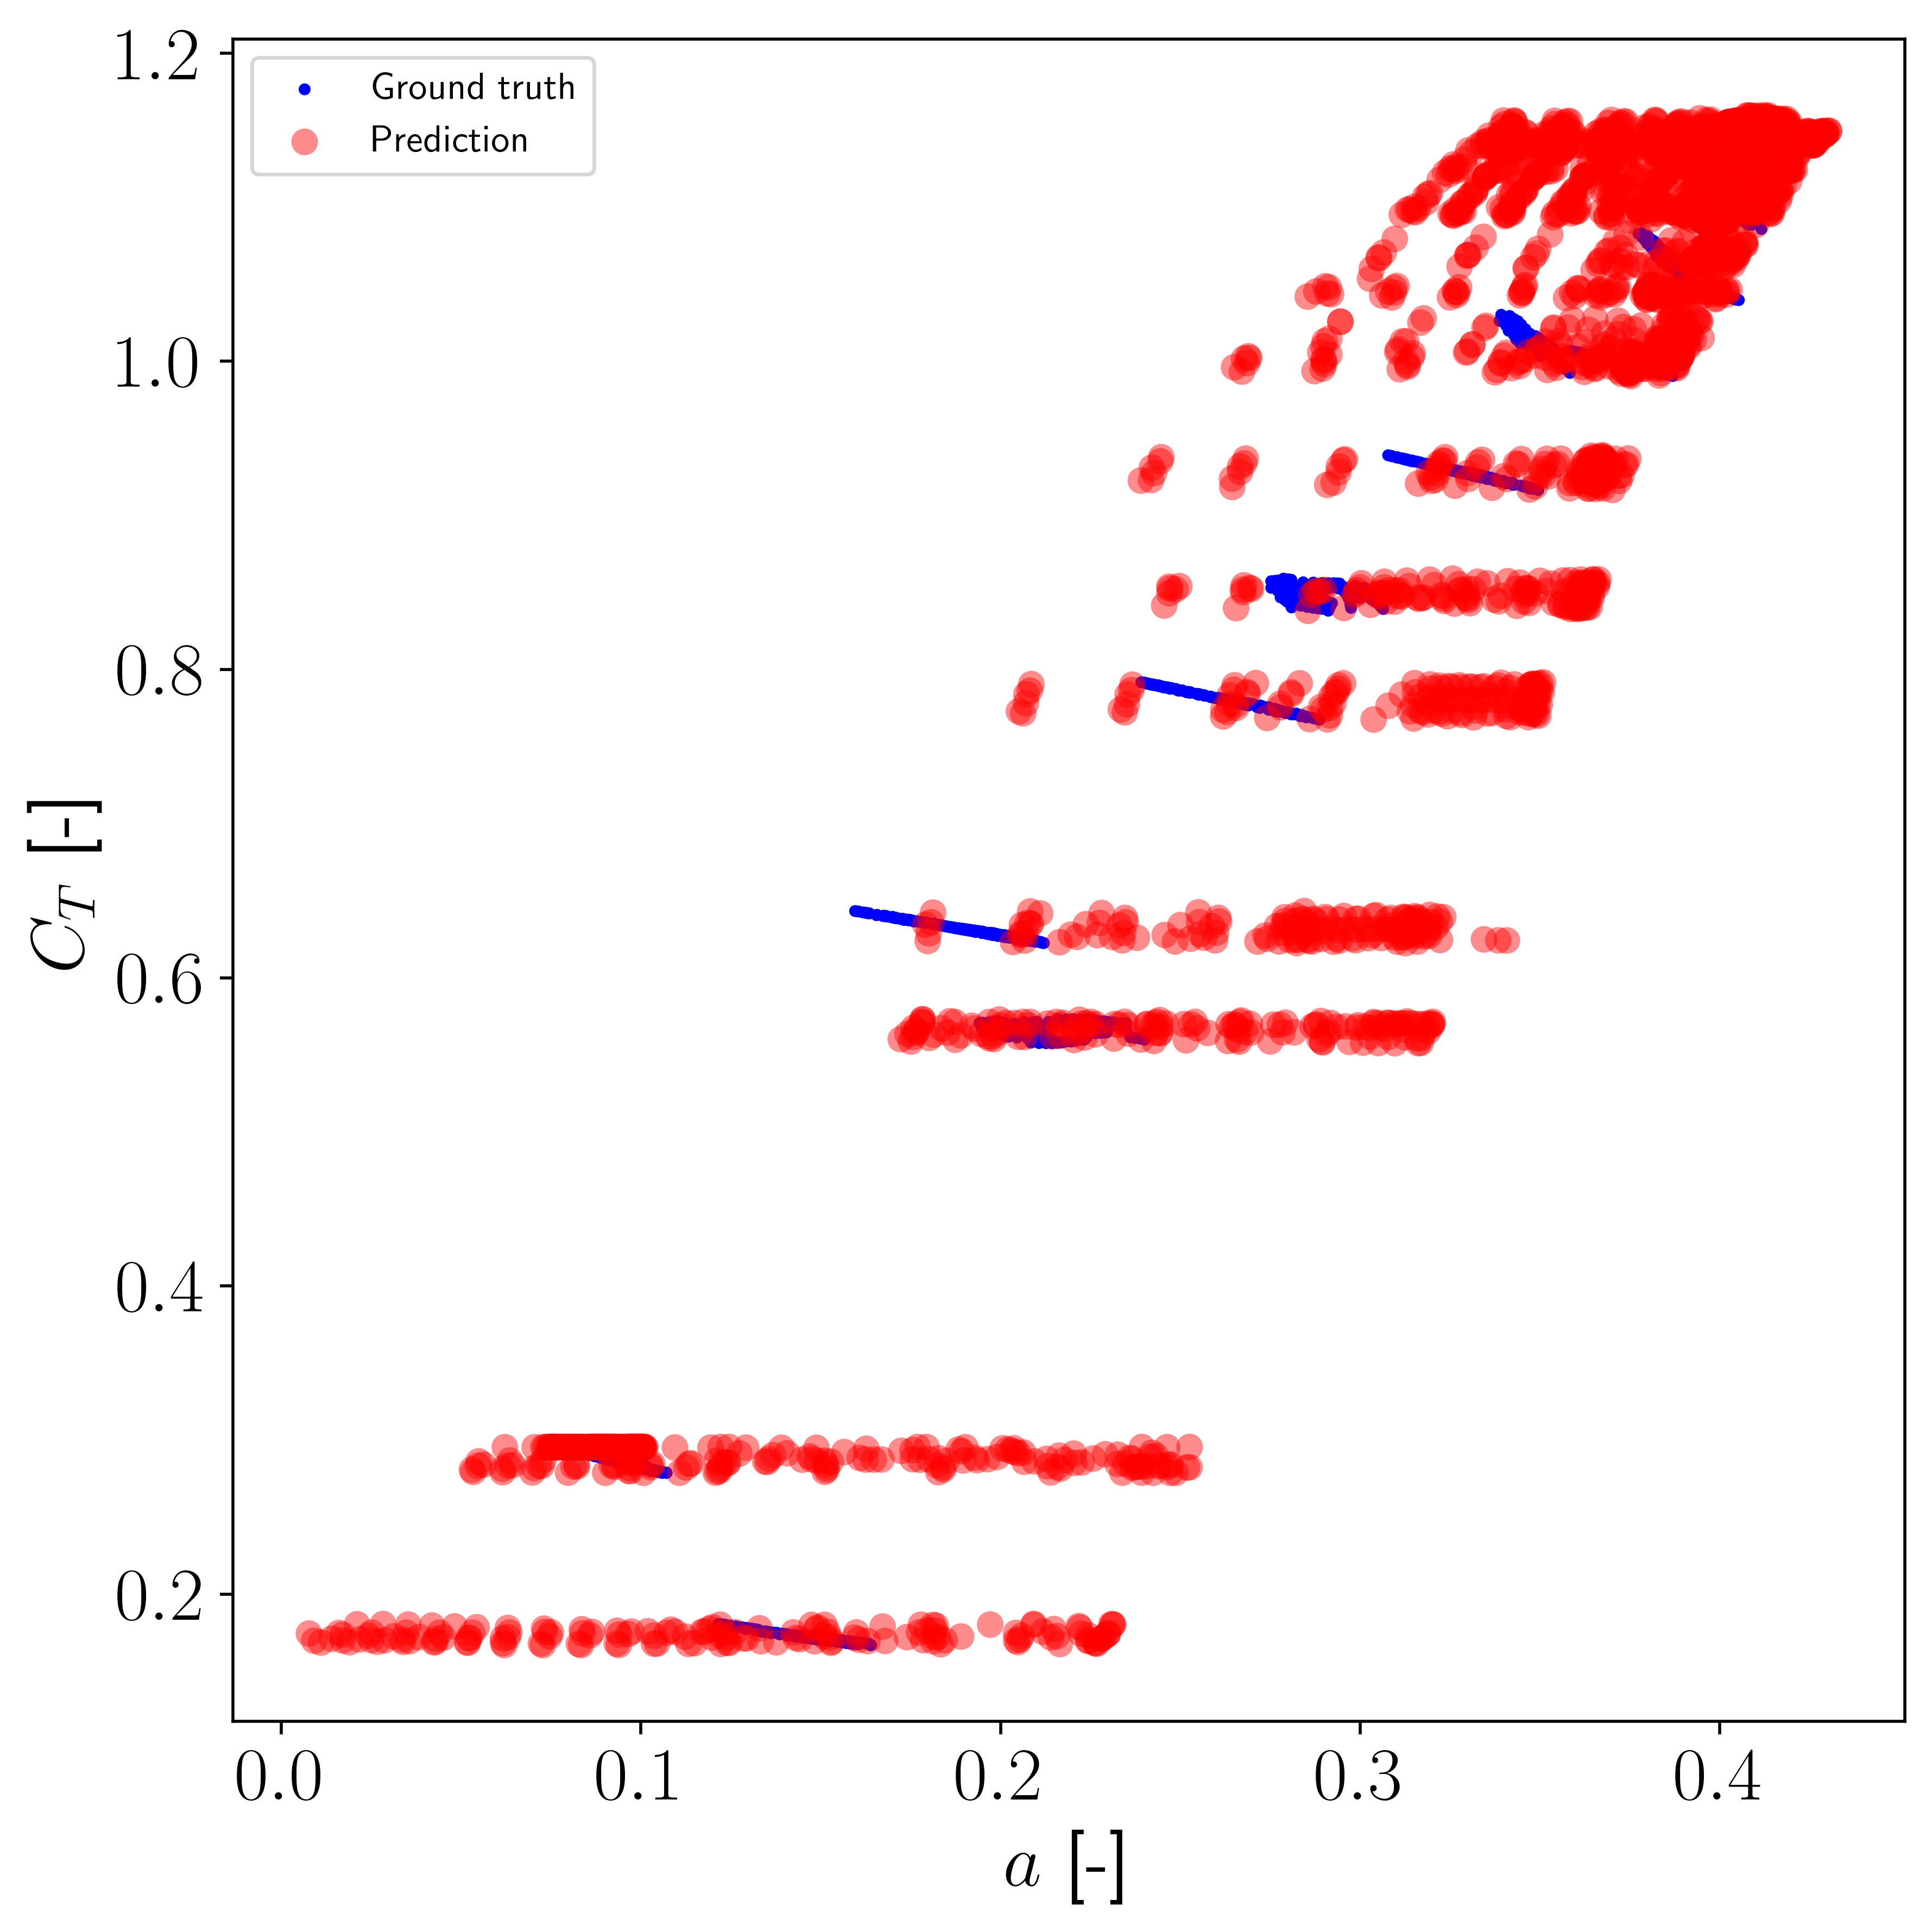

In [83]:
fig, ax = plt.subplots(figsize=(7, 7), constrained_layout=True,sharex=True, sharey=True)

mesh = ax.scatter(ind[:,:,6], ct[:,:,6], cmap='viridis', s=10, edgecolor='none',color='b',zorder=3,alpha=1,label='Ground truth')
mesh = ax.scatter(a_OOS[0], new_CT, cmap='viridis', s=50, edgecolor='none',color='r',zorder=3,alpha=0.45,label='Prediction')

ax.legend()

ax.set_ylabel('$C_T$ [-]', fontsize=20)
ax.set_xlabel('$a$ [-]', fontsize=20)